In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("/Users/mayurimamdi/Downloads/Books_Data_Clean.csv")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

In [30]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In here, min of publishing year is -560, and I need to fix it 

In [31]:
df.shape

(1070, 15)

In [32]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [33]:
df = df[df['Publishing Year'] > 1800]

In [34]:
df.shape

(1050, 15)

In [35]:
df.isnull().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          50
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

I need to delete all missing book name feature since there is no point keeping it as we need to do analysis on Books

In [37]:
df.dropna(subset='Book Name', inplace=True)

In [38]:
df.shape

(1029, 15)

In [39]:
df.duplicated().sum()

np.int64(0)

So no duplicates found

Lets see some Graphs

Text(0, 0.5, 'Frequency')

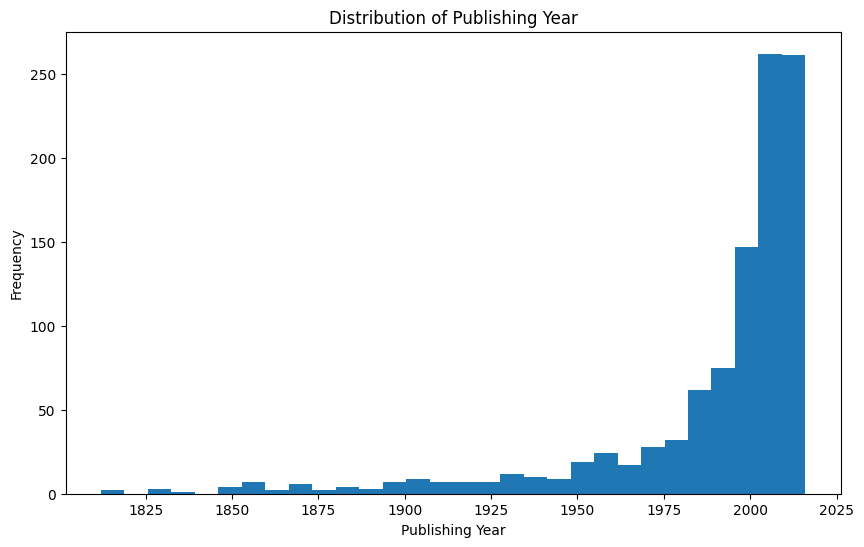

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(df['Publishing Year'], bins=30)
plt.title('Distribution of Publishing Year')
plt.xlabel('Publishing Year')
plt.ylabel('Frequency')

In [51]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False)


Author
Bill Watterson                  4.650
Bill Watterson, G.B. Trudeau    4.610
J.R.R. Tolkien                  4.590
George R.R. Martin              4.560
Sarah J. Maas                   4.526
                                ...  
Audrey Niffenegger              3.230
Herman Koch, Sam Garrett        3.220
Stephen Crane                   3.210
P.D. James                      3.210
Sue Monk Kidd                   3.100
Name: Book_average_rating, Length: 708, dtype: float64

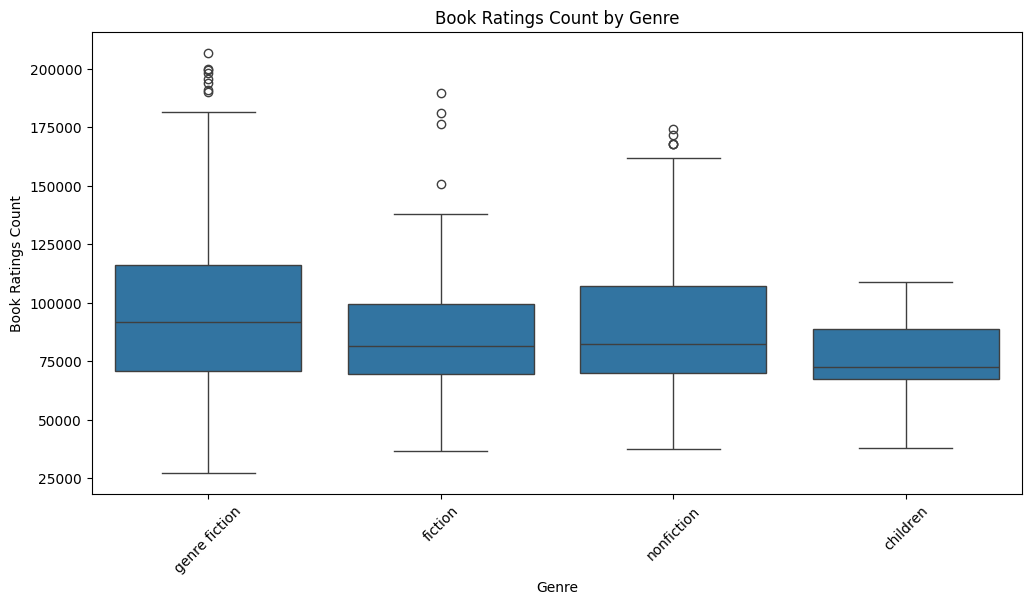

In [58]:


plt.figure(figsize=(12,6))
sns.boxplot(
    x='genre',
    y='Book_ratings_count',
    data=df
)

plt.title('Book Ratings Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Book Ratings Count')
plt.xticks(rotation=45)

plt.show()